# Taxi

The **Taxi problem** involves navigating passengers in a grid world, picking them up and dropping them off at one of four locations (Red, Green, Yellow and Blue) in a 5x5 grid world. The taxi starts off at a random square and the passenger at one of the designated locations. The goal is move the taxi to the passenger’s location, pick up the passenger, move to the passenger’s desired destination, and drop off the passenger. Once the passenger is dropped off, the episode ends.

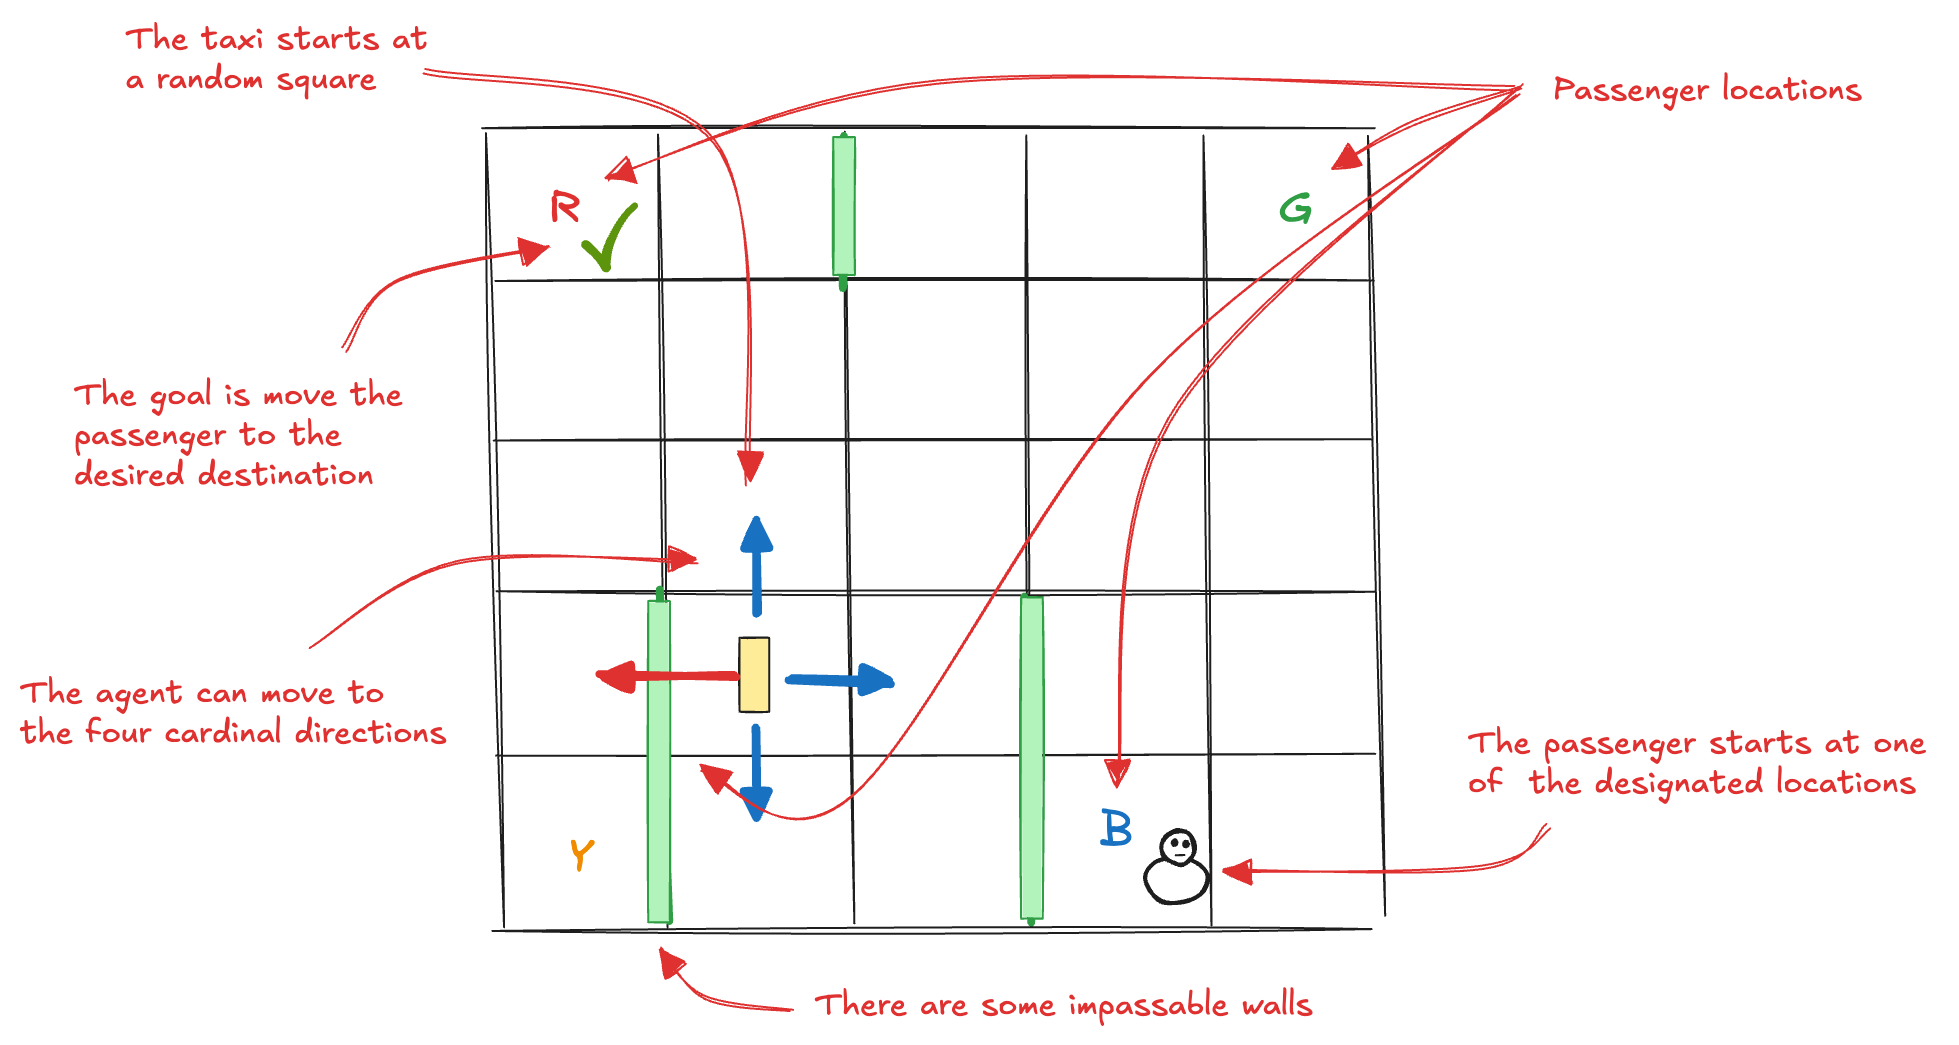

There are six possible actions. The agent can move to the four cardinal directions (south, north, east or west) and two other possible actions which are the pick-up or the drop-off:

- 0: Move south (down)
- 1: Move north (up)
- 2: Move east (right)
- 3: Move west (left)
- 4: Pickup passenger
- 5: Drop off passenger

The state is described by the taxi location on the grid (a row and a column number between 0 and 4), a location to drop-off the passenger from four choices, and the passenger which can be in one of the four locations or inside the taxi, in total 500 discrete states. An observation is returned as an int that encodes the corresponding state, calculated by: 
((taxi_row * 5 + taxi_col) * 5 + passenger_location) * 4 + destination

The player receives positive rewards for successfully dropping-off the passenger at the correct location. Negative rewards for incorrect attempts to pick-up/drop-off passenger and for each step where another reward is not received.

How large is the space of deterministic policies here? With $|\mathcal S|=500$ states and $|\mathcal A|=6$ actions, an exhaustive brute-force search would need to consider:

$\displaystyle N_{\text{BF}}=|\mathcal A|^{|\mathcal S|}=6^{500}$

a number with 390 digits, vastly larger than FrozenLake's already-intractable $4^{16}\approx4.3$ billion. This is exactly the kind of state space where dynamic programming's polynomial-time algorithms (policy evaluation, policy improvement, value iteration) turn an utterly hopeless search into a solvable problem.

1 - Import the 'Taxi-v3' grid word from Gymnasium:

In [1]:
# You can get the environment from Gymnasium in the same way we got 'Frozen Lake’; 
# in order to visually plot the environment you can import it 
# using render_mode="rgb_array"

import gymnasium as gym
taxi = gym.make('Taxi-v3', render_mode="rgb_array")

2 - Create a random policy as a baseline:

In [2]:
# You have to create a function that get in input a state and provide a random action
# (in the range [0;5])

import numpy as np

def pi_random(s):
    return np.random.choice(tuple(taxi.unwrapped.P[0].keys()))

3 - Show the policy in action by rendering the environment several times after different decisions from the random policy:

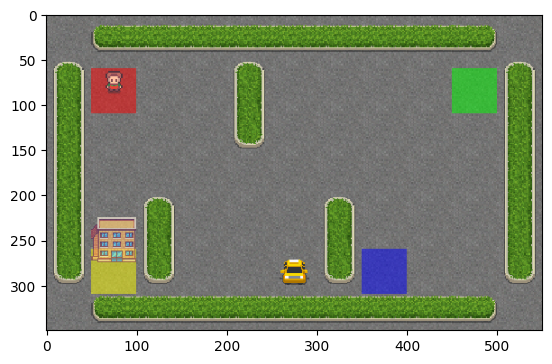

Step : 50 Action:  0


In [3]:
# You have to use a while loop in order to provide the current state to 
# the policy and then make a step in the environment using the action 
# provided by the policy. 
# Try to create a function (to be called "show_policy") 
# to be reused with other policies later.
# Hints: env.render() provides you an array representing 
# an image of the environment; plt.imshow() can be used to visualize 
# the image on the screen.

import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

def show_policy(env, pi, n_episodes=1, max_steps=50):
    for _ in range(n_episodes):
        state, info = env.reset()
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = pi(state)
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            clear_output(wait=True)
            plt.imshow(env.render())
            plt.show()
            steps += 1
            print('Step :',steps, 'Action: ', action)
            time.sleep(0.5)

show_policy(taxi, pi_random)

4 - Write an empirical evaluation function in order to evaluate the probability of success and the average return obtained by a policy, then evaluate the random policy:

In [4]:
# You can reuse the "evaluate" function that we already apply to 
# the Frozen Lake environment, however pay attention on how to determine 
# the end of an episode (it is no more state 15). 
# Hints: you have the "done" information from step function.

def evaluate(env, pi, n_episodes=1000):
    success = 0
    returns = []
    for _ in range(n_episodes):
        done = False
        steps = 0
        state, info = env.reset()
        returns.append(0.0)
        while not done:
            state, reward, terminated, truncated, info = env.step(pi(state))
            done = terminated or truncated
            returns[-1] += reward
            steps += 1
        # NOTE: for Taxi-v3, terminated=True happens only on a successful
        # drop-off, so this correctly counts "success". This assumption does
        # NOT hold for every environment (e.g. FrozenLake, where terminated
        # is also True after falling into a hole) -- check env semantics
        # before reusing this function elsewhere.
        if terminated:
            success += 1
    return (success/n_episodes)*100, np.mean(returns)

probability_success, mean_return = evaluate(taxi, pi_random)

print("Reaches goal ", probability_success, "%")
print("Obtains an average undiscounted return of ", mean_return)

Reaches goal  4.9 %
Obtains an average undiscounted return of  -765.965


5 - Use the **value-iteration algorithm** to calculate the optimal policy and also the optimal state-value function:

In [5]:
# You can reuse the "value_iteration" function that we already 
# apply to the Frozen Lake environment.

def value_iteration(env, gamma=0.99, theta=1e-10):

    # Access the complete transition model of the environment.
    # Dynamic programming assumes that these dynamics are known.
    dynamics = env.unwrapped.P

    # Initialize V_0 arbitrarily; zero is a common choice.
    V = np.zeros(len(dynamics))

    # Count the number of complete state-space sweeps required for convergence.
    sweeps = 0

    # Repeatedly apply the Bellman optimality update until convergence.
    while True:

        # # Initialize the action value function for the current iteration
        Q = np.zeros((len(dynamics), env.action_space.n))

        # Sweep through all states and actions.
        for s in range(len(dynamics)):
            for a in range(env.action_space.n):

                # Consider all possible transitions from state s under action a.
                for prob, next_state, reward, done in dynamics[s][a]:

                    # Compute the expected return of taking action a.
                    # Terminal transitions have no future value.
                    continuation = 0.0 if done else gamma * V[next_state]
                    Q[s, a] += prob * (reward + continuation)

        # For each state, keep the value of the best available action.
        new_V = np.max(Q, axis=1)

        # Measure the largest change produced by this sweep.
        delta = np.max(np.abs(new_V - V))

        # Update the state-value function.
        V = new_V

        # One complete sweep through the state space has been performed.
        sweeps += 1

        # Stop when the values change by less than the chosen tolerance.
        if delta < theta:
            break

    # Once the values have converged, extract a greedy optimal policy.
    def pi(s):
        return np.argmax(Q[s])

    # Return the optimal state-value function and an optimal policy.
    return V, pi, sweeps

v_best, pi_best, _ = value_iteration(taxi, gamma=0.99)

6 - Calculate the performance of the obtained optimal policy using the empirical evaluation approach:

In [6]:
# You can reuse the "evaluation" function written before, 
# in order to evaluate the optimal policy

probability_success, mean_return = evaluate(taxi, pi_best)
print("Reaches goal ", probability_success, "%")
print("Obtains an average undiscounted return of ", mean_return)

Reaches goal  100.0 %
Obtains an average undiscounted return of  8.031


7 - Show the optimal policy:

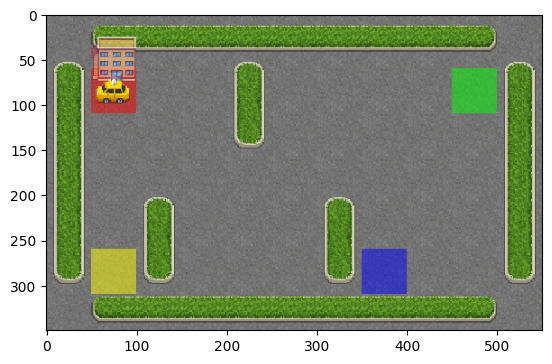

Step : 13 Action:  5


In [7]:
# You can reuse the "show_policy" function written before, 
# in order to show the optimal policy

show_policy(taxi, pi_best, n_episodes=5)

8 - We already used value iteration to solve Taxi. As a further exercise, let's also solve it with **policy iteration**, and compare how much computational effort each algorithm actually requires on a problem this much larger than FrozenLake (500 states and 6 actions, instead of 16 states and 4 actions).

In [8]:
# Policy evaluation, policy improvement and policy iteration, reused from the
# Dynamic Programming notes (adapted to also count sweeps/cycles).

def policy_evaluation(pi, env, gamma=0.99, theta=1e-10):
    dynamics = env.unwrapped.P
    prev_V = np.zeros(len(dynamics))
    sweeps = 0
    while True:
        V = np.zeros(len(dynamics))
        for s in range(len(dynamics)):
            action = pi(s)
            for prob, next_state, reward, done in dynamics[s][action]:
                continuation = 0.0 if done else gamma * prev_V[next_state]
                V[s] += prob * (reward + continuation)
        sweeps += 1
        delta = np.max(np.abs(V - prev_V))
        if delta < theta:
            break
        prev_V = V.copy()
    return V, sweeps

def policy_improvement(V, env, gamma=0.99):
    dynamics = env.unwrapped.P
    n_states = len(dynamics)
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))
    for s in range(n_states):
        for a in range(n_actions):
            for prob, next_state, reward, done in dynamics[s][a]:
                continuation = 0.0 if done else gamma * V[next_state]
                Q[s, a] += prob * (reward + continuation)
    def new_pi(s):
        return np.argmax(Q[s])
    return new_pi

def policy_iteration(env, gamma=0.99, theta=1e-10):
    dynamics = env.unwrapped.P
    actions = tuple(dynamics[0].keys())
    random_actions = {s: np.random.choice(actions) for s in range(len(dynamics))}
    def pi(s):
        return random_actions[s]
    total_sweeps, cycles = 0, 0
    while True:
        V, sweeps = policy_evaluation(pi, env, gamma, theta)
        new_pi = policy_improvement(V, env, gamma)
        total_sweeps += sweeps
        cycles += 1
        policy_stable = all(pi(s) == new_pi(s) for s in range(len(dynamics)))
        if policy_stable:
            break
        pi = new_pi
    return V, new_pi, cycles, total_sweeps

In [9]:
import time

# Run Policy Iteration and measure its execution time.
# (This can take up to a minute on Taxi -- much larger than FrozenLake.)
t0 = time.perf_counter()
V_pi_taxi, pi_pi_taxi, pi_cycles, pi_sweeps = policy_iteration(taxi, gamma=0.99)
t_pi = time.perf_counter() - t0

# Run Value Iteration and measure its execution time.
t0 = time.perf_counter()
V_vi_taxi, pi_vi_taxi, vi_sweeps = value_iteration(taxi, gamma=0.99)
t_vi = time.perf_counter() - t0

print(f"Policy Iteration: {pi_cycles} evaluate-improve cycles, {pi_sweeps} total sweeps, {t_pi*1000:.1f} ms")
print(f"Value Iteration:  {vi_sweeps} total sweeps, {t_vi*1000:.1f} ms")

Policy Iteration: 17 evaluate-improve cycles, 36936 total sweeps, 14260.3 ms
Value Iteration:  19 total sweeps, 15.7 ms


On Taxi, policy iteration requires relatively few evaluation–improvement cycles, but each cycle may spend substantial computation evaluating an intermediate policy almost to convergence. Value iteration, instead, reaches the same optimal state-value function with far fewer sweeps and substantially less computation in this experiment. The difference, which was barely noticeable on FrozenLake’s small state space, becomes much more evident on Taxi. It provides a concrete illustration of the trade-off discussed earlier: policy iteration performs fewer but more expensive cycles, whereas value iteration performs cheaper sweeps that directly drive the value function toward optimality.